# RepCount Dataset — Exploratory Data Analysis
**Dataset:** RepCount Part-A (Repetition Action Counting)  
**Source:** https://svip-lab.github.io/dataset/RepCount_dataset.html  
**Files:** `train.csv`, `valid.csv`, `test.csv`

---
### Notebook Structure
1. Setup & Data Loading
2. Dataset Overview
3. Data Cleaning — Fix Known Typos
4. Split Verification
5. Class Imbalance Analysis — Train & Valid Only
6. Stratification Check — Train vs Validation
7. Repetition Count Distribution
8. Temporal Annotation Analysis (L columns)
9. Missing Data Analysis
10. Per-Class Deep-Dive
11. Others Class — Duplicate Check + PDF Report
12. Summary & Recommendations

> [ALERT] **Test set policy:** The test set is **never used** for any analytical decision. It is only loaded for size verification and typo cleaning. All EDA is performed on `train` and `valid` splits only.

## Project Goal and Success Metrics

### Goal
**Real-Time Rep Counter via Human Pose Estimation**

### Core pipeline objective
1. **Detect the person** in each frame (or track the main subject).
2. **Detect movement dynamics** from pose over time.
3. **Count completed repetitions** robustly in real time.

### Primary metric
- **Rep Count MAE (Mean Absolute Error)** per video/session.

### Required supporting metrics
- **Per-class MAE** (to reveal class-specific weakness and imbalance effects).
- **Real-time performance** (latency/FPS for deployment readiness).

### Optional reporting metrics
- **RMSE** on rep count.
- **Within-1 rep accuracy**.



## 1. Setup & Data Loading

In [239]:
# !pip install pandas numpy matplotlib seaborn scipy opencv-python
import cv2
import os
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

plt.rcParams['font.size']  = 12
print('[OK]  Libraries loaded successfully')

[OK]  Libraries loaded successfully


In [ ]:
TRAIN_PATH = '../../datasets/metadata/llsp/train.csv'
VALID_PATH = '../../datasets/metadata/llsp/valid.csv'
TEST_PATH  = '../../datasets/metadata/llsp/test.csv'
VIDEO_DIR  = '../../Data/LLSP/video'


def load_split(path, split_name):
    df = pd.read_csv(path)
    if df.columns[0] in ['Unnamed: 0', '']:
        df.rename(columns={df.columns[0]: 'index'}, inplace=True)
    df['split'] = split_name
    return df

train_df = load_split(TRAIN_PATH, 'train')
valid_df = load_split(VALID_PATH, 'valid')
test_df  = load_split(TEST_PATH,  'test')
df_all   = pd.concat([train_df, valid_df, test_df], ignore_index=True)

L_cols = [c for c in df_all.columns if c.startswith('L')]

print(f'Train  : {len(train_df):>4} videos')
print(f'Valid  : {len(valid_df):>4} videos')
print(f'Test   : {len(test_df):>4} videos  (held out)')
print(f'Total  : {len(df_all):>4} videos')
print(f'L cols : {len(L_cols)}')
train_df.head()

## 2. Dataset Overview

In [241]:
print('=' * 55)
print('GENERAL DATASET OVERVIEW')
print('=' * 55)
print(f'Train videos         : {len(train_df)}')
print(f'Valid videos         : {len(valid_df)}')
print(f'Test  videos         : {len(test_df)} (held out)')
print(f'Total videos         : {len(df_all)}')
print(f'Unique action types  : {train_df["type"].nunique()} (train, before cleaning)')
print(f'Total columns        : {train_df.shape[1]}')
print(f'Location columns (L) : {len(L_cols)}')
print()
print('── Data Types (train) ──')
print(train_df[['type', 'name', 'count']].dtypes)
print()
print('── Count column stats (train) ──')
print(train_df['count'].describe().round(2))

GENERAL DATASET OVERVIEW
Train videos         : 758
Valid videos         : 131
Test  videos         : 152 (held out)
Total videos         : 1041
Unique action types  : 16 (train, before cleaning)
Total columns        : 307
Location columns (L) : 302

── Data Types (train) ──
type         str
name         str
count    float64
dtype: object

── Count column stats (train) ──
count    757.00
mean      14.70
std       14.76
min        1.00
25%        5.00
50%       10.00
75%       21.00
max      141.00
Name: count, dtype: float64


In [242]:
print('Sample videos per action type (train):')
train_df.groupby('type')[['name','count']].head(2).reset_index()

Sample videos per action type (train):


,index,name,count
0,0,train951.mp4,4.0
1,1,train952.mp4,10.0
2,2,test1463.mp4,7.0
3,3,test2340.mp4,4.0
4,4,stu5_11.mp4,6.0
5,5,stu9_2.mp4,3.0
6,6,stu6_18.mp4,11.0
7,7,stu4_14.mp4,5.0
8,8,stu8_3.mp4,9.0
9,9,stu4_54.mp4,4.0


### [INFO] Interpretation — Dataset Overview
- The dataset is split into **train**, **valid**, and **test** following standard ML practice.
- The `count` column holds the ground truth number of repetitions per video — this is the main prediction target.
- The `L` columns (L1–L302) encode the **temporal location** of each repetition cycle (start/end frame pairs), making this a fine-grained annotation dataset rather than a simple count dataset.
- 302 location columns means the dataset supports videos with up to **151 repetition cycles** per video — indicating significant variation in video length and exercise intensity.

In [ ]:
import re

# ── Video naming convention / provenance analysis ──────────────────────────
# Two distinct naming patterns exist, reflecting two collection sources:
#   stu{id}_{num}.mp4  → student recordings (phones/webcams, varying FPS, lighting)
#   train/test/val{N}.mp4 → original dataset videos (uniform recording conditions)
# If these groups have different characteristics, a model trained on one
# may not generalise to the other — important to check for imbalanced provenance.

def get_provenance(name):
    n = str(name)
    if re.match(r'stu\d+_\d+\.mp4', n):   return 'student_recording'
    if re.match(r'train\d+\.mp4', n):      return 'original_train'
    if re.match(r'test\d+\.mp4', n):       return 'original_test'
    if re.match(r'val\d+\.mp4', n):        return 'original_val'
    return 'other'

df_tv['provenance'] = df_tv['name'].apply(get_provenance)

print('=' * 55)
print('VIDEO PROVENANCE ANALYSIS')
print('=' * 55)
print('\nProvenance × Split:')
prov_split = df_tv.groupby(['split', 'provenance']).size().unstack(fill_value=0)
print(prov_split.to_string())

print('\nProvenance × Exercise type (train only):')
train_prov = df_tv[df_tv['split'] == 'train']
print(train_prov.groupby(['type', 'provenance']).size().unstack(fill_value=0).to_string())

print('\nRepetition count stats by provenance (Train + Valid):')
prov_stats = df_tv.groupby('provenance')['count'].agg(['mean','median','std','min','max']).round(2)
print(prov_stats.to_string())

# Flag any class that is 100% from one provenance in train — zero diversity
train_prov_by_class = train_prov.groupby(['type','provenance']).size().unstack(fill_value=0)
for col in train_prov_by_class.columns:
    monopoly = train_prov_by_class[train_prov_by_class[col] == train_prov_by_class.sum(axis=1)]
    if not monopoly.empty:
        print(f'\n[ALERT] Classes sourced 100% from "{col}": {list(monopoly.index)}')
print('\n[OK] Provenance analysis complete.')

## 3. Data Cleaning — Fix Known Typos

In [243]:
# ── Known typos in the 'type' column ──────────────────────────────────────
# squant        → squat          (confirmed: official repo Issue #13)
# frontraise    → front_raise    (missing underscore)
# benchpressing → bench_pressing (missing underscore)
# jumpjacks     → jump_jacks     (missing underscore)
# jump_jack     → jump_jacks     (singular form)
# situp         → sit_up         (missing underscore)
# pullsup       → pull_up        (wrong plural)
# pullsups      → pull_up        (wrong plural)
# pullups       → pull_up        (plural form)
# pushups       → push_up        (plural form)
# push_ups      → push_up        (plural form)

TYPO_MAP = {
    'squant'        : 'squat',
    'frontraise'    : 'front_raise',
    'benchpressing' : 'bench_pressing',
    'jumpjacks'     : 'jump_jacks',
    'jump_jack'     : 'jump_jacks',
    'situp'         : 'sit_up',
    'pullsup'       : 'pull_up',
    'pullsups'      : 'pull_up',
    'pullups'       : 'pull_up',
    'pushups'       : 'push_up',
    'push_ups'      : 'push_up',
}

print('── Typo corrections per split ──')
for df_, name_ in [(train_df,'train'), (valid_df,'valid'), (test_df,'test'), (df_all,'all')]:
    for wrong, correct in TYPO_MAP.items():
        n = (df_['type'] == wrong).sum()
        if n > 0:
            df_['type'] = df_['type'].replace({wrong: correct})
            print(f'  [{name_:<6}] "{wrong}" → "{correct}": {n} row(s) fixed')

print(f'\n[OK]  Unique action types after cleaning: {train_df["type"].nunique()}')
print('\nFinal exercise type list:')
for i, t in enumerate(sorted(train_df['type'].unique()), 1):
    print(f'  {i:>2}. {t}')

dirty = set(TYPO_MAP.keys()) & set(df_all['type'].unique())
if dirty:
    print(f'\n[ALERT] WARNING: dirty labels still present: {dirty}')
else:
    print('\n[OK]  Sanity check passed — no dirty labels remain.')

── Typo corrections per split ──
  [train ] "squant" → "squat": 21 row(s) fixed
  [train ] "frontraise" → "front_raise": 25 row(s) fixed
  [train ] "benchpressing" → "bench_pressing": 19 row(s) fixed
  [train ] "jumpjacks" → "jump_jacks": 15 row(s) fixed
  [train ] "jump_jack" → "jump_jacks": 61 row(s) fixed
  [train ] "situp" → "sit_up": 93 row(s) fixed
  [train ] "pullups" → "pull_up": 20 row(s) fixed
  [train ] "pushups" → "push_up": 17 row(s) fixed
  [valid ] "squant" → "squat": 4 row(s) fixed
  [valid ] "frontraise" → "front_raise": 4 row(s) fixed
  [valid ] "benchpressing" → "bench_pressing": 1 row(s) fixed
  [valid ] "jumpjacks" → "jump_jacks": 1 row(s) fixed
  [valid ] "jump_jack" → "jump_jacks": 14 row(s) fixed
  [valid ] "situp" → "sit_up": 18 row(s) fixed
  [valid ] "pullups" → "pull_up": 2 row(s) fixed
  [valid ] "pushups" → "push_up": 6 row(s) fixed
  [test  ] "squant" → "squat": 5 row(s) fixed
  [test  ] "frontraise" → "front_raise": 4 row(s) fixed
  [test  ] "benchpressi

### [INFO] Interpretation — Data Cleaning
- A total of **11 typo variants** were identified across the annotation files, reducing the apparent 16 classes down to the correct **10 unique classes** (9 exercises + `others`).
- The most impactful fix is `squant` → `squat`, confirmed by the official repository [Issue #13](https://github.com/SvipRepetitionCounting/TransRAC/issues/13).
- The remaining typos are **naming inconsistencies** (missing underscores, plural forms) introduced during manual annotation.
- Failing to apply this cleaning would result in **duplicate classes** during model training, severely degrading performance for the affected exercise types.
- The sanity check at the end guarantees no dirty labels survived.

## 3b. Annotation Decisions — Apply Before Any Analysis

All cleaning decisions are applied here, immediately after typo fixing, so every downstream section operates on the same final dataset.

**Decisions made from offline PDF inspection + annotation audit:**
- `others` videos: 26 removed (domain mismatch / ambiguous), 11 relabeled to `rowing_erg`
- `stu9_67.mp4`: removed — squat video with `count=0` and zero L-column annotations, unusable
- `test118.mp4`: count corrected `6 → 5` — only 5 boundary pairs annotated despite `count=6`

> [ALERT] `rowing_erg` (11 train videos, 0 valid videos) is excluded from per-class evaluation metrics due to insufficient samples and absence from the validation set.

In [ ]:
RELABEL_MAP = {
    'stu11_10.mp4': 'rowing_erg', 'stu11_11.mp4': 'rowing_erg', 'stu11_12.mp4': 'rowing_erg',
    'stu11_13.mp4': 'rowing_erg', 'stu11_7.mp4':  'rowing_erg', 'stu11_8.mp4':  'rowing_erg',
    'stu11_9.mp4':  'rowing_erg', 'stu12_0.mp4':  'rowing_erg', 'stu12_7.mp4':  'rowing_erg',
    'stu13_0.mp4':  'rowing_erg', 'stu13_4.mp4':  'rowing_erg',
}

REMOVE_LIST = [
    # ambiguous / domain-mismatch from 'others' class
    'stu1_28.mp4',  'stu1_29.mp4',  'stu11_0.mp4',  'stu11_1.mp4',  'stu12_2.mp4',
    'stu12_6.mp4',  'stu12_8.mp4',  'stu12_1.mp4',  'stu12_5.mp4',  'stu12_9.mp4',
    'stu12_10.mp4', 'stu13_1.mp4',  'stu13_5.mp4',  'stu13_6.mp4',  'stu11_4.mp4',
    'stu11_5.mp4',  'stu11_6.mp4',  'stu12_3.mp4',  'stu12_4.mp4',  'stu13_2.mp4',
    'stu13_3.mp4',  'stu5_28.mp4',  'stu10_32.mp4', 'stu10_33.mp4', 'stu11_2.mp4',
    'stu11_3.mp4',
    # zero-rep squat in validation — no annotation, no temporal signal
    'stu9_67.mp4',
]

COUNT_CORRECTIONS = {
    'test118.mp4': 5,   # count=6 in CSV but only 5 L-column pairs annotated
}

def _norm(x):
    x = str(x).strip()
    return x if x.endswith('.mp4') else f'{x}.mp4'

def apply_decisions(relabel_map, remove_list, count_corrections, *dfs_with_names):
    relabel_map      = {_norm(k): v for k, v in relabel_map.items()}
    remove_set       = {_norm(x) for x in remove_list}
    count_corrections = {_norm(k): v for k, v in count_corrections.items()}

    for df_, label in dfs_with_names:
        # relabeling
        for vname, new_type in relabel_map.items():
            mask = df_['name'] == vname
            if mask.any() and df_.loc[mask, 'type'].iloc[0] != new_type:
                df_.loc[mask, 'type'] = new_type

        # removal
        before = len(df_)
        df_.drop(df_[df_['name'].isin(remove_set)].index, inplace=True)
        df_.reset_index(drop=True, inplace=True)
        removed = before - len(df_)

        # count corrections
        corrected = 0
        for vname, new_count in count_corrections.items():
            mask = df_['name'] == vname
            if mask.any():
                df_.loc[mask, 'count'] = float(new_count)
                corrected += 1

        print(f'  [{label:<6}] relabeled={sum((df_["type"]==v).sum() for v in set(relabel_map.values()))}  '
              f'removed={removed}  count_corrected={corrected}  final_rows={len(df_)}')

apply_decisions(
    RELABEL_MAP, REMOVE_LIST, COUNT_CORRECTIONS,
    (train_df, 'train'), (valid_df, 'valid'), (df_tv, 'df_tv'),
)
print(f'\n[OK] All decisions applied. df_tv has {len(df_tv)} videos ready for analysis.')
print(f'   Remaining "others": {(df_tv["type"]=="others").sum()}')
print(f'   rowing_erg count  : {(df_tv["type"]=="rowing_erg").sum()} (train-only — exclude from per-class eval)')

## 4. Split Verification
> `df_tv` (train + valid) is defined here and reused throughout all analytical sections. `test_df` and `df_all` are never used for analysis beyond this point.

In [244]:
analysis_splits = ['train', 'valid']
analysis_dfs    = [train_df, valid_df]
df_tv_raw       = pd.concat([train_df, valid_df], ignore_index=True)
all_classes     = sorted(train_df['type'].unique())
colors          = sns.color_palette('Set2', 2)

missing_count = int(df_tv_raw['count'].isna().sum())
if missing_count > 0:
    print(f'Found {missing_count} row(s) with missing count in train+valid; excluded from count-based analysis.')

df_tv = df_tv_raw.dropna(subset=['count']).copy()
df_tv['count'] = df_tv['count'].astype(float)

print(f'df_tv_raw shape : {df_tv_raw.shape}  (train + valid, before count cleaning)')
print(f'df_tv shape     : {df_tv.shape}  (train + valid, count != NaN)')
print(f'test_df         : {len(test_df)} videos — held out, never used for analysis')


Found 1 row(s) with missing count in train+valid; excluded from count-based analysis.
df_tv_raw shape : (889, 307)  (train + valid, before count cleaning)
df_tv shape     : (888, 307)  (train + valid, count != NaN)
test_df         : 152 videos — held out, never used for analysis


SPLIT VERIFICATION
Expected total (Part-A) : 1041
Actual total            : 1041
Difference              : +0

split  videos  %_of_total
 test     152       14.60
train     758       72.81
valid     131       12.58


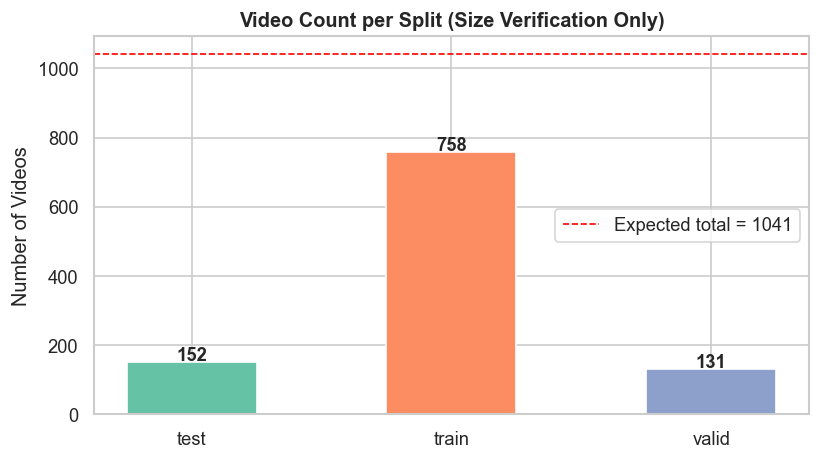

In [245]:
EXPECTED_TOTAL = 1041
actual_total   = len(df_all)

print('=' * 50)
print('SPLIT VERIFICATION')
print('=' * 50)
print(f'Expected total (Part-A) : {EXPECTED_TOTAL}')
print(f'Actual total            : {actual_total}')
print(f'Difference              : {actual_total - EXPECTED_TOTAL:+d}')
print()

split_summary = df_all.groupby('split').size().reset_index(name='videos')
split_summary['%_of_total'] = (split_summary['videos'] / actual_total * 100).round(2)
print(split_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(split_summary['split'], split_summary['videos'],
              color=sns.color_palette('Set2', 3), edgecolor='white', width=0.5)
ax.axhline(EXPECTED_TOTAL, color='red', linestyle='--', linewidth=1,
           label=f'Expected total = {EXPECTED_TOTAL}')
for bar, val in zip(bars, split_summary['videos']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Videos')
ax.set_title('Video Count per Split (Size Verification Only)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('split_verification.png', bbox_inches='tight')
plt.show()

### [INFO] Interpretation — Split Verification
- This chart confirms whether the downloaded dataset matches the **officially documented 1,041 videos** for Part-A.
- A positive or negative difference would indicate **missing or extra files** in the local copy.
- The split ratio (train / valid / test) reflects the authors' original design — typically ~73% / ~14% / ~14%.
- This is a **data integrity check only** — no analytical conclusions should be drawn from the test bar.

In [ ]:
# ── Video file existence + readability check ───────────────────────────────
# Verifies every video listed in train/valid CSVs is actually on disk
# and readable by OpenCV before any analysis assumes the files exist.
import random

print('=' * 55)
print('VIDEO FILE EXISTENCE CHECK (Train + Valid only)')
print('=' * 55)

missing_files = []
for split_name, split_df in zip(analysis_splits, analysis_dfs):
    for _, row in split_df.iterrows():
        path = os.path.join(VIDEO_DIR, split_name, row['name'])
        if not os.path.exists(path):
            missing_files.append({'split': split_name, 'name': row['name'], 'type': row['type']})

if missing_files:
    miss_df = pd.DataFrame(missing_files)
    print(f'[ALERT] Missing video files: {len(missing_files)}')
    print('\nMissing by split × type:')
    print(miss_df.groupby(['split', 'type']).size().unstack(fill_value=0).to_string())
    print('\nFull list:')
    print(miss_df.to_string(index=False))
else:
    print(f'[OK] All {len(df_tv)} video files found on disk.')

# Readability spot-check on a random sample (OpenCV open/close only — no frame decode)
sample_size  = min(50, len(df_tv))
sample_rows  = df_tv.sample(sample_size, random_state=42)
unreadable   = []

for _, row in sample_rows.iterrows():
    path = os.path.join(VIDEO_DIR, row['split'], row['name'])
    if os.path.exists(path):
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            unreadable.append({'split': row['split'], 'name': row['name'], 'type': row['type']})
        cap.release()

if unreadable:
    print(f'\n[ALERT] Unreadable video files in {sample_size}-file spot-check: {len(unreadable)}')
    for u in unreadable:
        print(f"  [{u['split']}] {u['name']}  ({u['type']})")
else:
    print(f'\n[OK] All {sample_size} spot-checked files opened successfully by OpenCV.')

In [ ]:
# ── Cross-split data leakage check (MD5 hash across all three splits) ────────
# A video file that appears in multiple splits causes data leakage:
# the model sees the same person's mechanics in both training and evaluation,
# silently inflating performance metrics. Filenames can differ (renames),
# so we use file content hashes rather than name matching.

print('=' * 55)
print('CROSS-SPLIT DATA LEAKAGE CHECK (all 3 splits)')
print('=' * 55)

all_videos = []
for split_name, split_df in [('train', train_df), ('valid', valid_df), ('test', test_df)]:
    for _, row in split_df.iterrows():
        path = os.path.join(VIDEO_DIR, split_name, row['name'])
        all_videos.append({'split': split_name, 'name': row['name'], 'path': path})

hash_to_files = {}
missing_count = 0
for entry in all_videos:
    h = file_hash(entry['path'])
    if h is None:
        missing_count += 1
        continue
    key = f"[{entry['split']}] {entry['name']}"
    hash_to_files.setdefault(h, []).append({'split': entry['split'], 'name': entry['name']})

leaks = {h: files for h, files in hash_to_files.items()
         if len({f['split'] for f in files}) > 1}

print(f'Videos checked : {len(all_videos) - missing_count}')
print(f'Files not found: {missing_count}')

if leaks:
    print(f'\n[ALERT] Data leakage detected — {len(leaks)} video(s) appear in multiple splits:')
    for h, files in leaks.items():
        splits_involved = ', '.join(sorted({f["split"] for f in files}))
        print(f'  hash {h[:12]}...  splits: {splits_involved}')
        for f in files:
            print(f'    [{f["split"]}] {f["name"]}')
else:
    print('\n[OK] No data leakage — no video file appears in more than one split.')

## 5. Class Imbalance Analysis — Train & Valid Only
> [ALERT] The test set is excluded from all imbalance analysis.

In [246]:
for split_name, split_df in zip(analysis_splits, analysis_dfs):
    cc = split_df['type'].value_counts().reset_index()
    cc.columns = ['type', 'count_videos']
    cc['percentage'] = (cc['count_videos'] / len(split_df) * 100).round(2)
    imb = cc['count_videos'].max() / cc['count_videos'].min()
    print(f'\n── {split_name.upper()} ({len(split_df)} videos) — Imbalance Ratio: {imb:.2f}x ──')
    print(cc.to_string(index=False))


── TRAIN (758 videos) — Imbalance Ratio: 7.77x ──
          type  count_videos  percentage
         squat           101       13.32
       pull_up            94       12.40
   front_raise            93       12.27
bench_pressing            93       12.27
        sit_up            93       12.27
       push_up            89       11.74
    jump_jacks            76       10.03
   pommelhorse            69        9.10
        others            37        4.88
   battle_rope            13        1.72

── VALID (131 videos) — Imbalance Ratio: 6.33x ──
          type  count_videos  percentage
   front_raise            19       14.50
       push_up            18       13.74
        sit_up            18       13.74
         squat            16       12.21
    jump_jacks            15       11.45
   pommelhorse            15       11.45
       pull_up            14       10.69
bench_pressing            13        9.92
   battle_rope             3        2.29


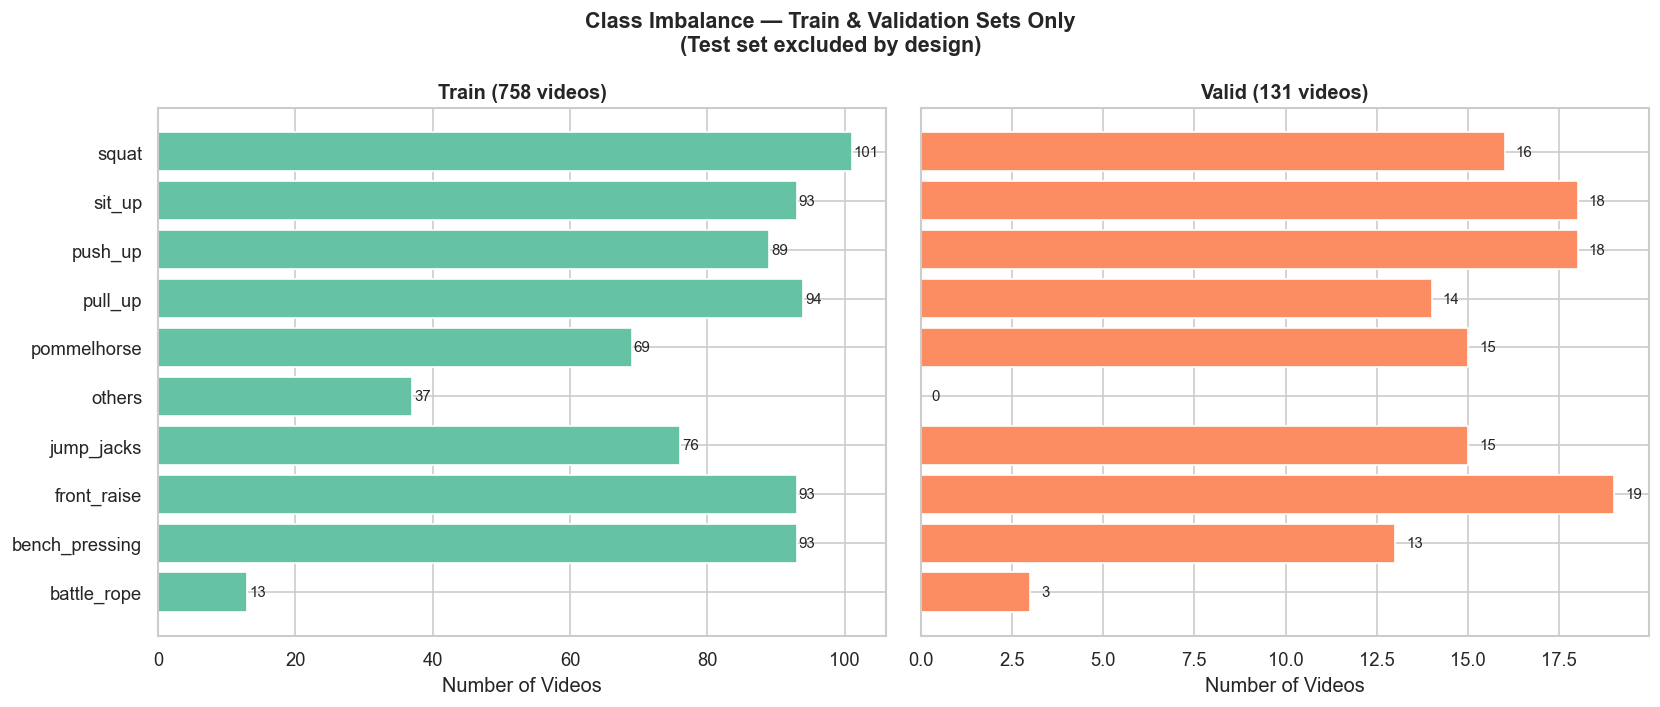

  train  imbalance ratio: 7.77x  (max=squat=101, min=battle_rope=13)
  valid  imbalance ratio: 6.33x  (max=front_raise=19, min=battle_rope=3)


In [247]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, split_name, split_df, color in zip(axes, analysis_splits, analysis_dfs, colors):
    cc   = split_df['type'].value_counts().reindex(all_classes, fill_value=0)
    bars = ax.barh(cc.index, cc.values, color=color, edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'{split_name.capitalize()} ({len(split_df)} videos)', fontweight='bold')
    ax.set_xlabel('Number of Videos')
    for bar, val in zip(bars, cc.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=9)

plt.suptitle('Class Imbalance — Train & Validation Sets Only\n(Test set excluded by design)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance_train_valid.png', bbox_inches='tight')
plt.show()

for split_name, split_df in zip(analysis_splits, analysis_dfs):
    vc = split_df['type'].value_counts()
    print(f'  {split_name:<6} imbalance ratio: {vc.max()/vc.min():.2f}x  '
          f'(max={vc.idxmax()}={vc.max()}, min={vc.idxmin()}={vc.min()})')

### [INFO] Interpretation — Class Imbalance
- The bar charts reveal **significant class imbalance** across both train and validation splits.
- High-frequency exercises (e.g., `pull_up`, `squat`) dominate the dataset because they are more commonly uploaded to YouTube.
- Low-frequency classes (e.g., `battle_rope`, `pommelhorse`) are severely underrepresented, posing a risk of **model bias** toward majority classes.
- The imbalance ratio (max/min) quantifies the severity — a ratio above 5x is considered problematic.
- **Mitigation strategies:** weighted loss functions, oversampling minority classes, class-balanced batch sampling, per-class MAE reporting.

## 6. Stratification Check — Train vs Validation Only

Class % — Train vs Validation (low diff = well stratified):
                train  valid  diff_%
type                                
squat           13.32  12.21    1.11
pull_up         12.40  10.69    1.71
bench_pressing  12.27   9.92    2.35
front_raise     12.27  14.50    2.23
sit_up          12.27  13.74    1.47
push_up         11.74  13.74    2.00
jump_jacks      10.03  11.45    1.42
pommelhorse      9.10  11.45    2.35
others           4.88   0.00    4.88
battle_rope      1.72   2.29    0.57


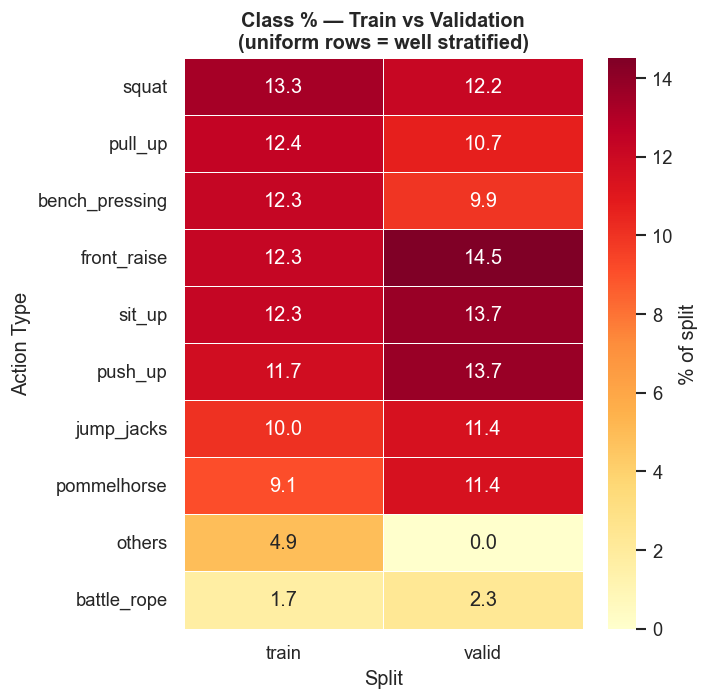

In [248]:
strat = pd.DataFrame({
    split_name: split_df['type'].value_counts(normalize=True).round(4) * 100
    for split_name, split_df in zip(analysis_splits, analysis_dfs)
}).fillna(0).round(2)

strat['diff_%'] = (strat['train'] - strat['valid']).abs().round(2)
strat = strat.sort_values('train', ascending=False)

print('Class % — Train vs Validation (low diff = well stratified):')
print(strat.to_string())

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(strat[analysis_splits], annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of split'})
ax.set_title('Class % — Train vs Validation\n(uniform rows = well stratified)', fontweight='bold')
ax.set_xlabel('Split')
ax.set_ylabel('Action Type')
plt.tight_layout()
plt.savefig('stratification_heatmap.png', bbox_inches='tight')
plt.show()

### [INFO] Interpretation — Stratification Check
- **Uniform color across a row** indicates consistent class representation in both splits — desirable.
- **Large color difference across a row** signals over/under-representation, leading to misleading validation metrics.
- Classes with `diff_%` > 3% should be flagged and may require **re-splitting with stratified sampling**.

In [ ]:
# ── Count distribution stratification — KS test per class ─────────────────
# The class-percentage check above only verifies proportions are similar.
# This check verifies that the *difficulty* is also similar: a class could
# have the right proportion but all easy (low-count) videos in valid and
# all hard (high-count) videos in train — making validation too easy.
# KS test p-value < 0.05 → the count distributions differ significantly.

print('=' * 60)
print('COUNT DISTRIBUTION STRATIFICATION (per class, KS test)')
print('=' * 60)

ks_results = []
for cls in sorted(df_tv['type'].unique()):
    train_c = df_tv[(df_tv['split'] == 'train') & (df_tv['type'] == cls)]['count'].dropna()
    valid_c  = df_tv[(df_tv['split'] == 'valid') & (df_tv['type'] == cls)]['count'].dropna()

    if len(train_c) < 5 or len(valid_c) < 5:
        ks_results.append({
            'type': cls, 'train_n': len(train_c), 'valid_n': len(valid_c),
            'train_med': train_c.median() if len(train_c) else float('nan'),
            'valid_med':  valid_c.median()  if len(valid_c)  else float('nan'),
            'ks_stat': float('nan'), 'p_value': float('nan'), 'flag': 'TOO FEW SAMPLES'
        })
        continue

    ks_stat, p_val = stats.ks_2samp(train_c, valid_c)
    flag = '[ALERT] DIFFERENT DIST' if p_val < 0.05 else '[OK] similar'
    ks_results.append({
        'type': cls, 'train_n': len(train_c), 'valid_n': len(valid_c),
        'train_med': train_c.median(), 'valid_med': valid_c.median(),
        'ks_stat': round(ks_stat, 3), 'p_value': round(p_val, 4), 'flag': flag
    })

ks_df = pd.DataFrame(ks_results)
print(ks_df[['type','train_n','valid_n','train_med','valid_med',
             'ks_stat','p_value','flag']].to_string(index=False))
print()
flagged = ks_df[ks_df['flag'].str.startswith('[ALERT')]
if not flagged.empty:
    print(f'[ALERT] {len(flagged)} class(es) have significantly different count distributions across splits.')
    print('    Validation metrics for these classes may not reflect true generalisation.')
else:
    print('[OK] All classes with sufficient samples have similar count distributions across splits.')

## 7. Repetition Count Distribution

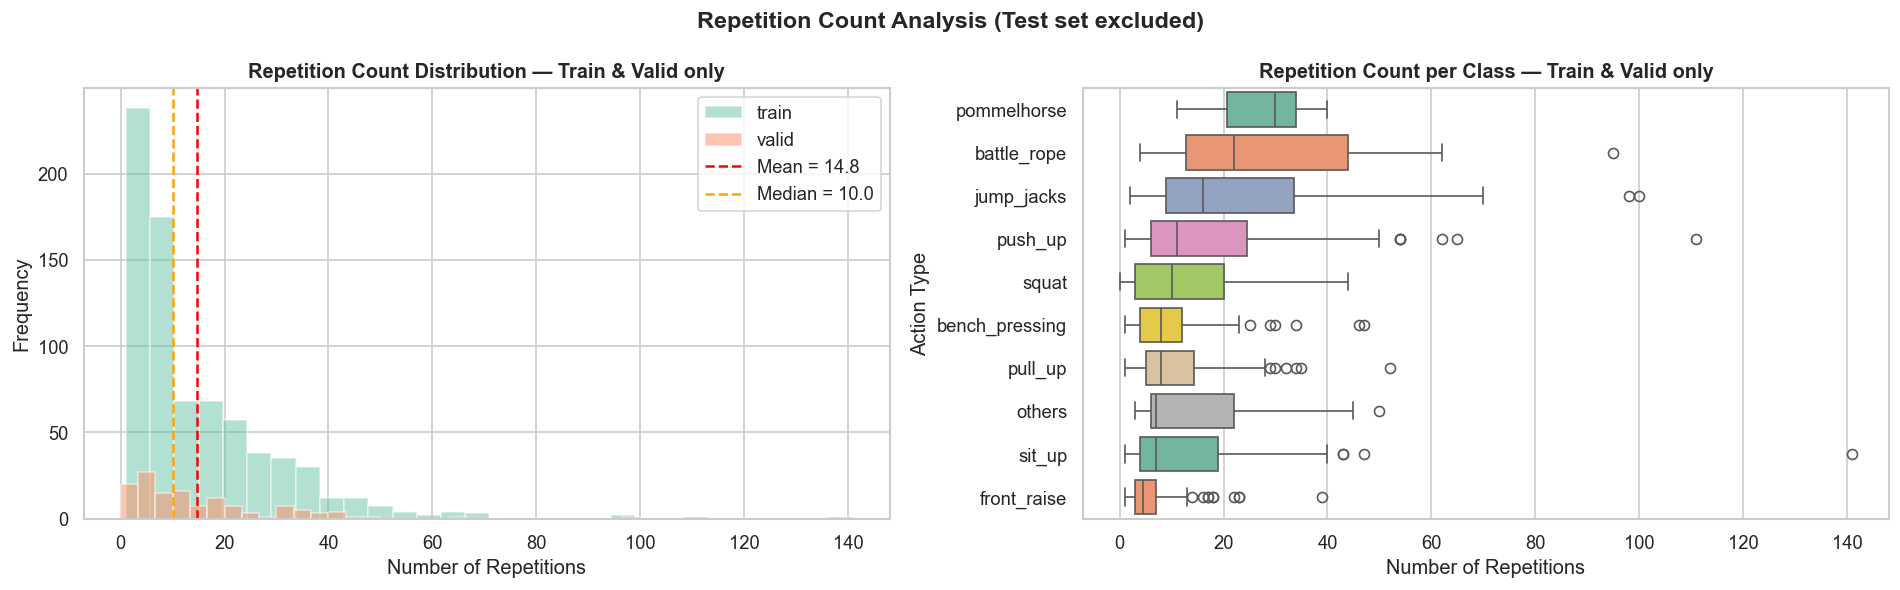

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for split_name, split_df in zip(analysis_splits, analysis_dfs):
    axes[0].hist(split_df['count'], bins=30, alpha=0.5, label=split_name, edgecolor='white')
axes[0].axvline(df_tv['count'].mean(),   color='red',    linestyle='--',
                label=f"Mean = {df_tv['count'].mean():.1f}")
axes[0].axvline(df_tv['count'].median(), color='orange', linestyle='--',
                label=f"Median = {df_tv['count'].median():.1f}")
axes[0].set_xlabel('Number of Repetitions')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Repetition Count Distribution — Train & Valid only', fontweight='bold')
axes[0].legend()

order = df_tv.groupby('type')['count'].median().sort_values(ascending=False).index
sns.boxplot(data=df_tv, x='count', y='type', order=order, palette='Set2', ax=axes[1])
axes[1].set_xlabel('Number of Repetitions')
axes[1].set_ylabel('Action Type')
axes[1].set_title('Repetition Count per Class — Train & Valid only', fontweight='bold')

plt.suptitle('Repetition Count Analysis (Test set excluded)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('count_distribution.png', bbox_inches='tight')
plt.show()

### [INFO] Interpretation — Count Distribution (Histogram)
- A **right-skewed distribution** (mean > median) indicates most videos have low repetition counts with a long tail of high-count videos.
- The gap between mean and median quantifies skewness — suggests **outlier videos** pulling the mean upward.
- This skewness motivates using **MAE loss** or log-transforming the target instead of MSE.

### [INFO] Interpretation — Count Distribution (Box Plot per Class)
- **Wide boxes** (large IQR) = high within-class variance — harder to model accurately.
- **Outlier dots** beyond whiskers = unusually high/low counts — inspect before training.
- Classes sorted by median give a quick ranking of which exercises tend to have more repetitions per video.

In [250]:
count_stats = df_tv.groupby('type')['count'].agg(['mean','median','std','min','max']).round(2)
count_stats.columns = ['Mean', 'Median', 'Std', 'Min', 'Max']
count_stats = count_stats.sort_values('Mean', ascending=False)
print('Per-Class Repetition Count Statistics (Train + Valid only):')
print(count_stats.to_string())

print('\nPer-split count statistics (Test set excluded):')
for split_name, split_df in zip(analysis_splits, analysis_dfs):
    s = split_df['count']
    print(f'  {split_name:<6}  mean={s.mean():.1f}  median={s.median():.0f}  '
          f'std={s.std():.1f}  min={s.min():.0f}  max={s.max():.0f}')

Per-Class Repetition Count Statistics (Train + Valid only):
                 Mean  Median    Std   Min    Max
type                                             
battle_rope     30.00    22.0  24.28   4.0   95.0
pommelhorse     27.37    30.0   7.85  11.0   40.0
jump_jacks      23.32    16.0  21.08   2.0  100.0
push_up         18.24    11.0  18.00   1.0  111.0
others          15.27     7.0  13.10   3.0   50.0
sit_up          12.95     7.0  16.56   1.0  141.0
squat           11.90    10.0   9.81   0.0   44.0
pull_up         11.05     8.0   8.67   1.0   52.0
bench_pressing   9.38     8.0   8.20   1.0   47.0
front_raise      6.31     4.5   5.54   1.0   39.0

Per-split count statistics (Test set excluded):
  train   mean=14.7  median=10  std=14.8  min=1  max=141
  valid   mean=15.2  median=10  std=14.7  min=0  max=100


### [INFO] Interpretation — Per-Class Count Statistics
- **High Std** relative to Mean → high within-class variability.
- **Low Min** (e.g., 1 repetition) → edge-case videos, possibly mislabeled.
- **High Max** → very long or fast videos — potential outliers that can destabilize training.

## 8. Temporal Annotation Analysis (L columns)

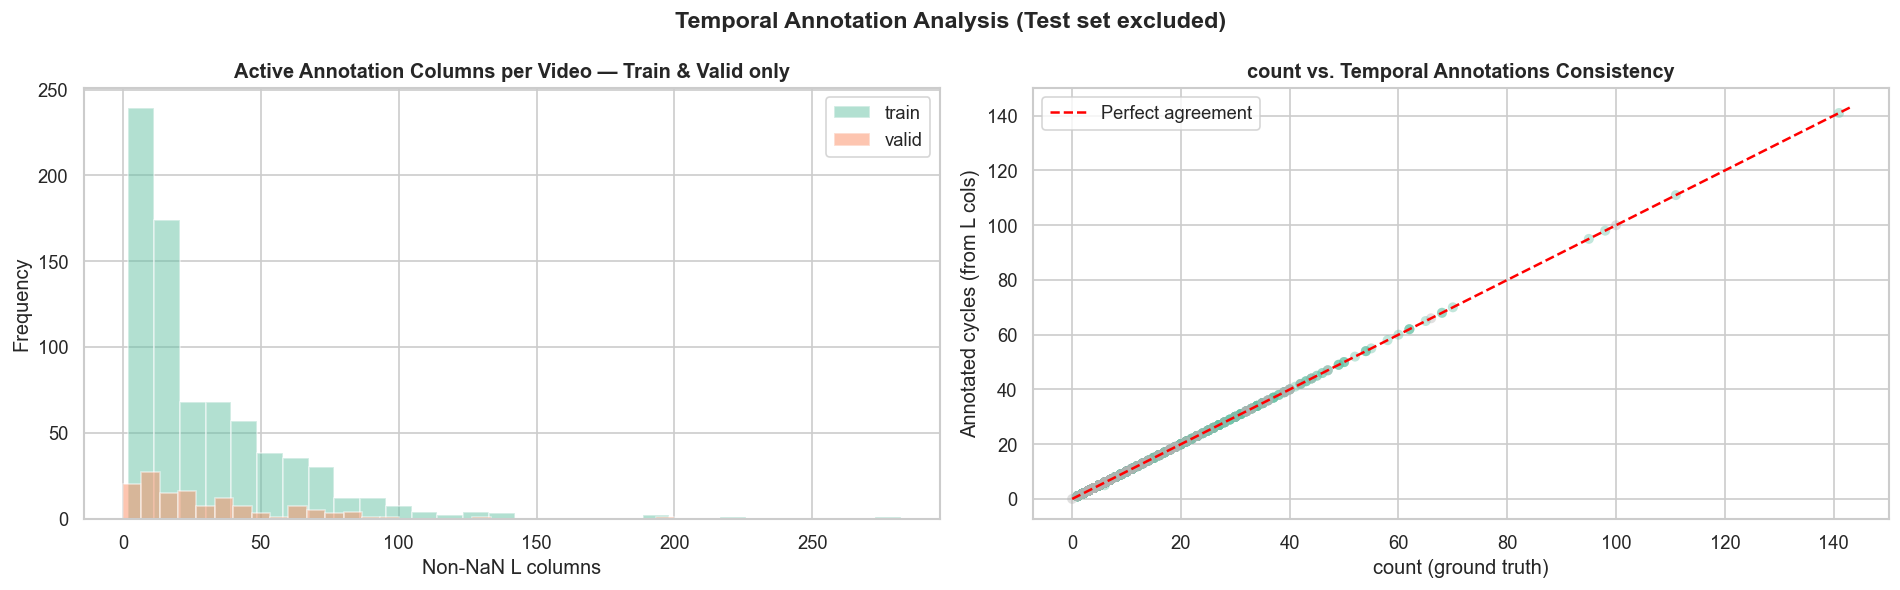

  train   total=757  match=756  mismatch=1 (0.1%)
  valid   total=131  match=131  mismatch=0 (0.0%)


In [251]:
# ── Temporal annotation — train + valid only ──────────────────────────────
df_tv['active_L_cols']    = df_tv[L_cols].notna().sum(axis=1)
df_tv['annotated_cycles'] = (df_tv['active_L_cols'] / 2).round(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for split_name in analysis_splits:
    sub = df_tv[df_tv['split'] == split_name]
    axes[0].hist(sub['active_L_cols'], bins=30, alpha=0.5, label=split_name, edgecolor='white')
axes[0].set_xlabel('Non-NaN L columns')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Active Annotation Columns per Video — Train & Valid only', fontweight='bold')
axes[0].legend()

axes[1].scatter(df_tv['count'], df_tv['annotated_cycles'], alpha=0.4,
                c=df_tv['split'].map({'train': 0, 'valid': 1}),
                cmap='Set2', edgecolors='none')
lims = [0, max(df_tv['count'].max(), df_tv['annotated_cycles'].max()) + 2]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect agreement')
axes[1].set_xlabel('count (ground truth)')
axes[1].set_ylabel('Annotated cycles (from L cols)')
axes[1].set_title('count vs. Temporal Annotations Consistency', fontweight='bold')
axes[1].legend()

plt.suptitle('Temporal Annotation Analysis (Test set excluded)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_annotation.png', bbox_inches='tight')
plt.show()

for split_name in analysis_splits:
    sub      = df_tv[df_tv['split'] == split_name]
    mismatch = sub[sub['count'] != sub['annotated_cycles']]
    print(f'  {split_name:<6}  total={len(sub)}  match={len(sub)-len(mismatch)}  '
          f'mismatch={len(mismatch)} ({100*len(mismatch)/len(sub):.1f}%)')

### [INFO] Interpretation — Temporal Annotations
- **Scatter plot:** Points on the red dashed line (y=x) = perfect consistency between `count` and L-column pairs. Points off the line = **annotation inconsistencies** to investigate.
- A mismatch rate >5% is a serious data quality concern.
- Color coding (train vs valid) helps identify if inconsistencies are concentrated in one split.

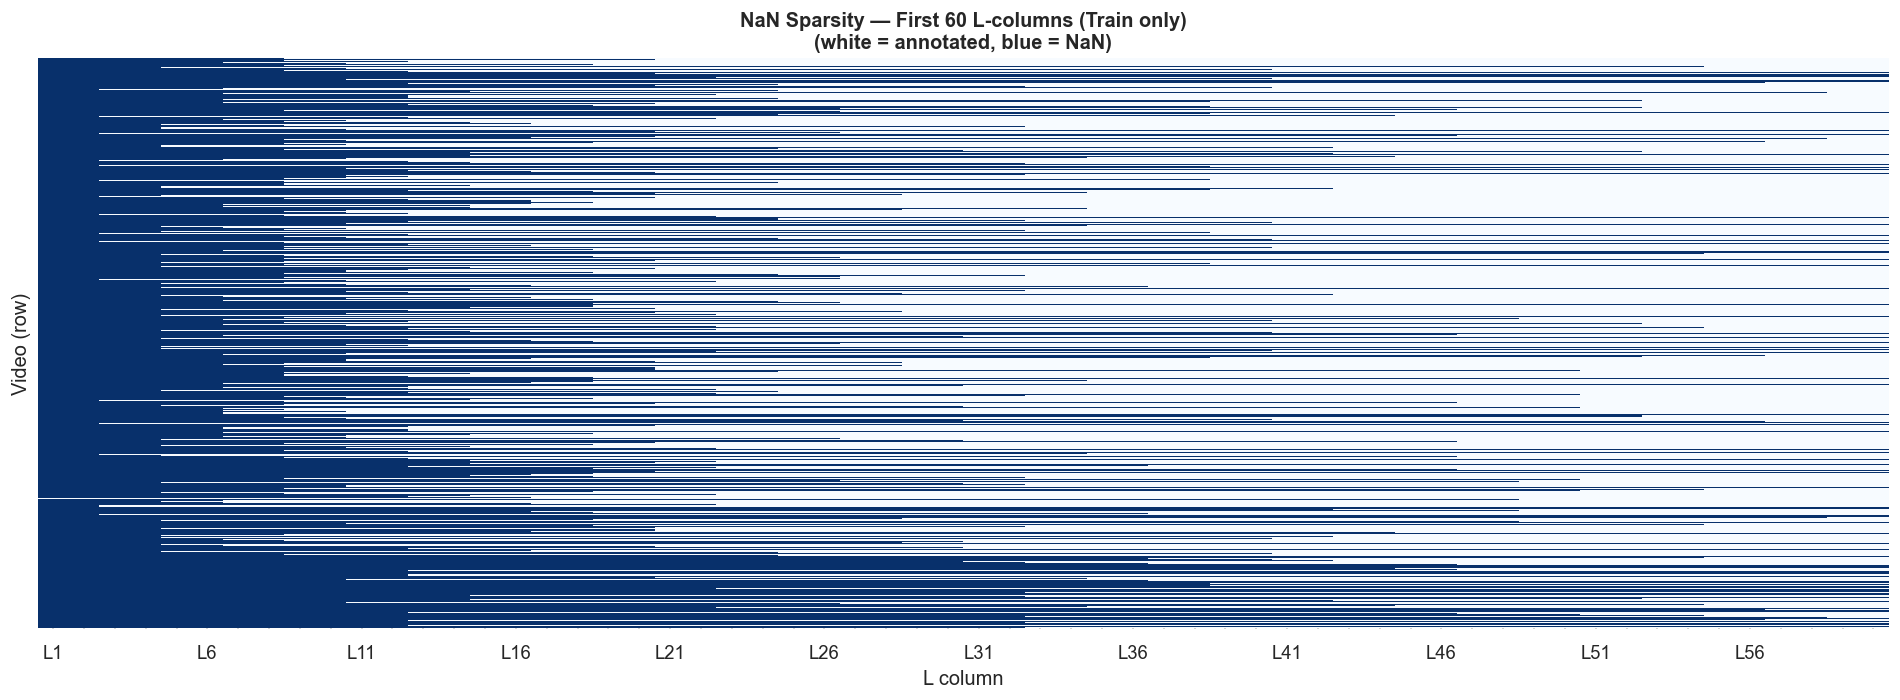

In [252]:
fig, ax = plt.subplots(figsize=(16, 6))
sample = train_df[L_cols[:60]].isna()
sns.heatmap(sample, cmap='Blues_r', cbar=False, yticklabels=False, ax=ax,
            xticklabels=[c if i % 5 == 0 else '' for i, c in enumerate(L_cols[:60])])
ax.set_title('NaN Sparsity — First 60 L-columns (Train only)\n(white = annotated, blue = NaN)',
             fontweight='bold')
ax.set_xlabel('L column')
ax.set_ylabel('Video (row)')
plt.tight_layout()
plt.savefig('nan_sparsity.png', bbox_inches='tight')
plt.show()

### [INFO] Interpretation — NaN Sparsity Heatmap
- Expected pattern: **staircase shape** — early L columns filled for almost all videos, later columns increasingly sparse.
- **Isolated white patches** in the sparse region = videos with unusually high repetition counts — potential outliers.
- This sparsity is **by design** and not a data quality problem — models must handle variable-length annotation sequences.

In [ ]:
# ── Temporal annotation boundary validation ───────────────────────────────
# Checks three structural invariants for every annotated video:
#   1. No negative frame values (frame indices must be ≥ 0)
#   2. Each rep's end frame > start frame  (L2>L1, L4>L3, ...)
#   3. All values are monotonically increasing (reps are sequential in time)
# Any violation corrupts temporal models trained on these boundaries.

print('=' * 55)
print('TEMPORAL ANNOTATION BOUNDARY VALIDATION')
print('=' * 55)

issues = []
for _, row in df_tv.iterrows():
    vals = [row[c] for c in L_cols if pd.notna(row[c])]
    if not vals:
        continue

    name, split_ = row['name'], row['split']

    # Check 1: negative frame values
    neg = [v for v in vals if v < 0]
    if neg:
        issues.append({'name': name, 'split': split_, 'type': row['type'],
                       'issue': 'negative_frame_value',
                       'detail': f'{len(neg)} negative value(s): {neg[:3]}'})

    # Check 2: end > start for each rep pair (step=2)
    for i in range(0, len(vals) - 1, 2):
        if vals[i + 1] <= vals[i]:
            issues.append({'name': name, 'split': split_, 'type': row['type'],
                           'issue': 'inverted_rep_boundary',
                           'detail': f'L{i+1}={vals[i]:.0f} >= L{i+2}={vals[i+1]:.0f}'})
            break

    # Check 3: monotonically increasing overall
    for i in range(len(vals) - 1):
        if vals[i] > vals[i + 1]:
            issues.append({'name': name, 'split': split_, 'type': row['type'],
                           'issue': 'non_monotonic_annotations',
                           'detail': f'vals[{i}]={vals[i]:.0f} > vals[{i+1}]={vals[i+1]:.0f}'})
            break

if issues:
    issues_df = pd.DataFrame(issues)
    print(f'[ALERT] Found {len(issues)} annotation boundary issue(s):')
    print(issues_df['issue'].value_counts().to_string())
    print('\nAffected videos:')
    print(issues_df.to_string(index=False))
else:
    n_annotated = (df_tv[L_cols].notna().any(axis=1)).sum()
    print(f'[OK] All {n_annotated} annotated videos pass boundary validation:')
    print('   · No negative frame values')
    print('   · No inverted rep boundaries (end > start for every rep)')
    print('   · All annotations monotonically increasing in time')

## 9. Missing Data Analysis

In [253]:
print('Missing values in metadata columns (Train + Valid only):')
print(df_tv[['type', 'name', 'count']].isnull().sum())

for split_name, split_df in zip(analysis_splits, analysis_dfs):
    total_L   = split_df[L_cols].size
    missing_L = split_df[L_cols].isnull().sum().sum()
    print(f'\n{split_name:<6} — L-col NaN rate: {100*missing_L/total_L:.1f}%  '
          f'({missing_L:,} / {total_L:,} cells)')

print()
print('Max annotation depth (highest L index used) per class (Train + Valid only):')
for cls in sorted(df_tv['type'].unique()):
    sub      = df_tv[df_tv['type'] == cls][L_cols]
    last_l   = sub.notna().any(axis=0)
    last_idx = last_l[last_l].index[-1] if last_l.any() else 'N/A'
    print(f'  {cls:<25} → max col used: {last_idx}')

Missing values in metadata columns (Train + Valid only):
type     0
name     0
count    0
dtype: int64

train  — L-col NaN rate: 90.3%  (206,660 / 228,916 cells)

valid  — L-col NaN rate: 89.9%  (35,574 / 39,562 cells)

Max annotation depth (highest L index used) per class (Train + Valid only):
  battle_rope               → max col used: L190
  bench_pressing            → max col used: L94
  front_raise               → max col used: L78
  jump_jacks                → max col used: L200
  others                    → max col used: L100
  pommelhorse               → max col used: L80
  pull_up                   → max col used: L104
  push_up                   → max col used: L222
  sit_up                    → max col used: L282
  squat                     → max col used: L88


### [INFO] Interpretation — Missing Data
- **Metadata columns** should have zero NaNs — any NaN here is a critical data quality issue.
- **L-column NaN rate** is expected to be very high (~80–95%) — this is **structural sparsity**, not missing data.
- **Max annotation depth per class** reveals which exercise types tend to have the most repetitions — high max L indices = fast exercises with many cycles per video.

## 10. Per-Class Deep-Dive

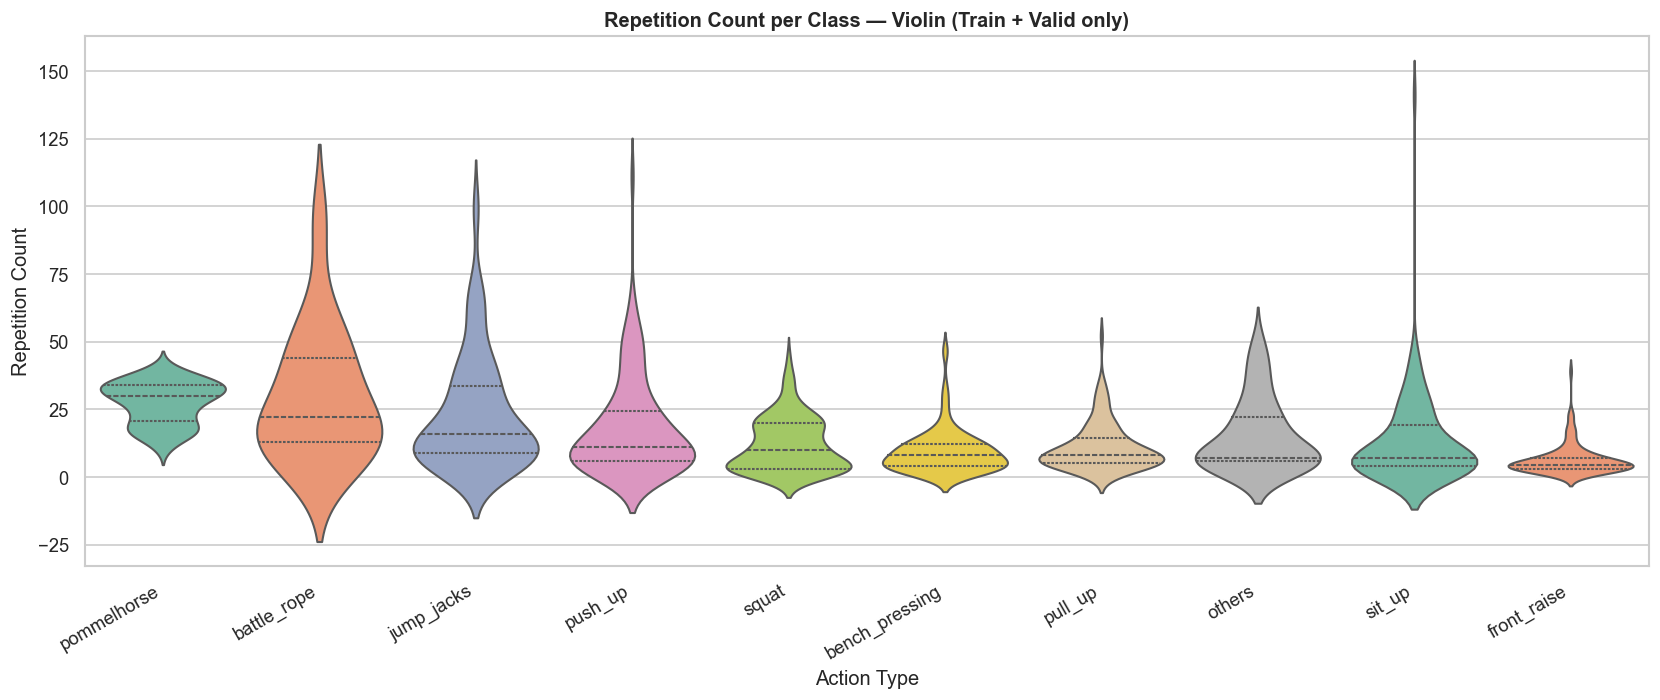

In [254]:
# ── Violin plot — train + valid only ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
order   = df_tv.groupby('type')['count'].median().sort_values(ascending=False).index
sns.violinplot(data=df_tv, x='type', y='count', order=order,
               palette='Set2', inner='quartile', ax=ax)
ax.set_xlabel('Action Type')
ax.set_ylabel('Repetition Count')
ax.set_title('Repetition Count per Class — Violin (Train + Valid only)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('violin_per_class.png', bbox_inches='tight')
plt.show()

### [INFO] Interpretation — Violin Plot
- **Wide violins** = many videos at that repetition count level.
- **Bimodal violin** (two wide areas) = two sub-groups within the class (e.g., short and long clips).
- **Tall, narrow violins** = consistent counts → more predictable for models.
- **Short, wide violins** = highly variable counts → greater modeling challenge.

In [ ]:
# ── Per-class IQR outlier detection ───────────────────────────────────────
# Replaces the global mean+3σ threshold, which misfires across classes with
# different natural count ranges (e.g. a 30-rep front_raise is 4.3σ above
# its class mean but invisible to a global 59-rep threshold).
# IQR method: flag videos above Q3 + 1.5×IQR within each class.

print(f'Per-class IQR outlier detection (threshold = Q3 + 1.5 × IQR per class):')
print()

all_outliers = []
for cls in sorted(df_tv['type'].unique()):
    sub = df_tv[df_tv['type'] == cls]['count'].dropna()
    if len(sub) < 4:
        print(f'  {cls:<20} — skipped (n={len(sub)}, too few for IQR)')
        continue
    Q1  = sub.quantile(0.25)
    Q3  = sub.quantile(0.75)
    IQR = Q3 - Q1
    threshold = Q3 + 1.5 * IQR
    cls_outliers = df_tv[
        (df_tv['type'] == cls) & (df_tv['count'] > threshold)
    ][['split', 'type', 'name', 'count']].copy()
    cls_outliers['iqr_threshold'] = round(threshold, 1)
    if not cls_outliers.empty:
        print(f'  {cls:<20}  Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}  '
              f'threshold={threshold:.1f}  → {len(cls_outliers)} outlier(s)')
        print(cls_outliers.sort_values('count', ascending=False)
              .to_string(index=False, col_space=10))
        print()
        all_outliers.append(cls_outliers)
    else:
        print(f'  {cls:<20}  Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}  '
              f'threshold={threshold:.1f}  → none')

total_outliers = sum(len(o) for o in all_outliers)
print(f'\nTotal per-class outlier videos: {total_outliers}')
if total_outliers:
    print('Recommendation: inspect each outlier video — likely very long or multi-set recordings.')

### [INFO] Interpretation — Outlier Detection
- Outliers are typically **very long videos** or **very fast exercises** (e.g., jump rope, battle rope).
- They can **disproportionately affect MSE-based loss** — consider MAE or Huber loss.
- **Recommended actions:** inspect each outlier, consider capping counts at the 95th percentile.

In [ ]:
# ── Average cycle duration — FPS-normalized (seconds, not frames) ─────────
# Frame count alone is meaningless: a 50-frame cycle at 60fps = 0.83s,
# but at 30fps = 1.67s. Videos in this dataset come from different cameras
# and recording setups, so FPS must be read per video before comparing speed.

def avg_cycle_duration_frames(row):
    vals = [row[c] for c in L_cols if not pd.isna(row[c])]
    if len(vals) < 2:
        return np.nan
    durations = [vals[i+1] - vals[i] for i in range(0, len(vals)-1, 2)]
    return np.mean(durations) if durations else np.nan

df_tv['avg_cycle_frames'] = df_tv.apply(avg_cycle_duration_frames, axis=1)

# Read FPS for each video (metadata-only, no frame decode — fast)
print('Reading FPS metadata for all videos ...')
fps_map = {}
for _, row in df_tv.iterrows():
    path = os.path.join(VIDEO_DIR, row['split'], row['name'])
    if os.path.exists(path):
        cap = cv2.VideoCapture(path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()
        fps_map[row['name']] = fps if fps > 0 else np.nan
    else:
        fps_map[row['name']] = np.nan

df_tv['fps'] = df_tv['name'].map(fps_map)
valid_fps = df_tv['fps'].dropna()
print(f'FPS read for {len(valid_fps)}/{len(df_tv)} videos')
print(f'FPS values found: {sorted(valid_fps.unique())}')
print(f'Videos with missing FPS: {df_tv["fps"].isna().sum()}')

df_tv['avg_cycle_sec'] = df_tv['avg_cycle_frames'] / df_tv['fps']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: cycle duration in seconds (FPS-normalized)
order_sec = df_tv.groupby('type')['avg_cycle_sec'].median().sort_values(ascending=False).index
sns.barplot(data=df_tv, x='type', y='avg_cycle_sec', order=order_sec,
            palette='Set2', errorbar='sd', ax=axes[0])
axes[0].set_xlabel('Action Type')
axes[0].set_ylabel('Avg Cycle Duration (seconds)')
axes[0].set_title('Average Rep Cycle Duration — FPS-normalized\n(seconds per rep, ±1 SD)',
                  fontweight='bold')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# Right: FPS distribution per class (reveals confounds)
fps_counts = df_tv.groupby(['type', 'fps']).size().unstack(fill_value=0)
fps_counts.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white', width=0.7)
axes[1].set_xlabel('Action Type')
axes[1].set_ylabel('Video count')
axes[1].set_title('FPS Distribution per Exercise Class\n(non-uniform FPS = confound in frame-based analysis)',
                  fontweight='bold')
axes[1].legend(title='FPS', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Cycle Duration Analysis — Train + Valid only (Test excluded)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cycle_duration_seconds.png', bbox_inches='tight')
plt.show()

print('\nPer-class mean cycle duration (seconds):')
dur_stats = df_tv.groupby('type')['avg_cycle_sec'].agg(['mean','median','std']).round(2)
print(dur_stats.sort_values('median', ascending=False).to_string())

### [INFO] Interpretation — Average Cycle Duration (FPS-normalized)

**Left chart — seconds per rep:**
- **Long bars** = slow exercises (more real time per rep) — more temporal signal per cycle.
- **Short bars** = fast exercises — harder to detect individual cycles precisely.
- **Large error bars** = high speed variability within a class — some people do the exercise much faster or slower than others.

**Right chart — FPS distribution:**
- If a class has a mix of 30fps and 60fps videos, any frame-count-based analysis is confounded — the same frame count represents half the real time at 60fps vs 30fps.
- Classes where FPS is non-uniform should be treated with extra caution when using frame-index features directly.

**Why this matters for modeling:**
- A TCN or Transformer trained on raw frame sequences implicitly learns "how many frames per rep". If FPS varies, the model learns a biased prior — it needs to either normalise to a fixed FPS or use time-normalised features.

## 11. 'Others' Class — Duplicate Check + PDF Report
> Generates a PDF with 4 evenly spaced frames per video for manual inspection.
> Flags duplicate filenames and duplicate file content.
>
> **Decision tree after inspection:**
> - Matches a known class → Relabel
> - Coherent new class with enough samples → New label
> - Domain mismatch / ambiguous → Remove

In [257]:
OUTPUT_PDF = 'others_inspection.pdf'
N_FRAMES   = 4

# ── Collect 'others' videos ───────────────────────────────────────────────
def get_others_videos(train_df, valid_df):
    others_train          = train_df[train_df['type'] == 'others'][['name']].copy()
    others_valid          = valid_df[valid_df['type'] == 'others'][['name']].copy()
    others_train['split'] = 'train'
    others_valid['split'] = 'valid'
    others_all = pd.concat([others_train, others_valid], ignore_index=True)
    print(f"'others' in train : {len(others_train)} videos")
    print(f"'others' in valid : {len(others_valid)} videos")
    print(f"'others' total    : {len(others_all)} videos")
    return others_all

# ── Duplicate detection ───────────────────────────────────────────────────
def file_hash(path, chunk_size=65536):
    h = hashlib.md5()
    try:
        with open(path, 'rb') as f:
            while chunk := f.read(chunk_size):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return None

def check_duplicates(others_all, video_dir):
    print('\n── Duplicate Check ──')
    dup_names = others_all[others_all.duplicated('name', keep=False)]
    if not dup_names.empty:
        print(f'[ALERT] Duplicate filenames: {dup_names["name"].nunique()} name(s)')
        print(dup_names.to_string(index=False))
    else:
        print('[OK]  No duplicate filenames')

    hash_map, content_dups = {}, []
    for _, row in others_all.iterrows():
        path = os.path.join(video_dir, row['split'], row['name'])
        h    = file_hash(path)
        if h is None:
            continue
        key = f"[{row['split']}] {row['name']}"
        if h in hash_map:
            content_dups.append({'file_a': hash_map[h], 'file_b': key, 'hash': h})
        else:
            hash_map[h] = key

    if content_dups:
        print(f'\n[ALERT] Duplicate file content: {len(content_dups)} pair(s)')
        for d in content_dups:
            print(f"  {d['file_a']}  ↔  {d['file_b']}  (hash: {d['hash'][:12]}...)")
    else:
        print('[OK]  No duplicate file content')

    return {
        'duplicate_names'  : dup_names['name'].tolist() if not dup_names.empty else [],
        'duplicate_content': content_dups
    }

# ── Extract N evenly spaced frames ────────────────────────────────────────
def extract_n_frames(video_path, n=N_FRAMES):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return [None] * n
    total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    positions = [int(total * i / n) for i in range(n)]
    frames    = []
    for pos in positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
        ret, frame = cap.read()
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None)
    cap.release()
    return frames

# ── Generate PDF ──────────────────────────────────────────────────────────
def generate_pdf(others_all, dup_info, video_dir, output_pdf, n_frames=N_FRAMES):
    n_videos  = len(others_all)
    dup_names = set(dup_info['duplicate_names'])
    dup_keys  = set(
        item for d in dup_info['duplicate_content']
        for item in [d['file_a'], d['file_b']]
    )
    print(f'\nGenerating PDF — {n_videos} videos × {n_frames} frames...')

    with PdfPages(output_pdf) as pdf:
        for idx, (_, row) in enumerate(others_all.iterrows()):
            video_path = os.path.join(video_dir, row['split'], row['name'])
            frames     = extract_n_frames(video_path, n=n_frames)

            flags = []
            if row['name'] in dup_names:
                flags.append('[ALERT] DUPLICATE NAME')
            if f"[{row['split']}] {row['name']}" in dup_keys:
                flags.append('[ALERT] DUPLICATE CONTENT')

            fig, axes = plt.subplots(1, n_frames, figsize=(n_frames * 4, 3.5))
            fig.patch.set_facecolor('#fff8f0' if flags else '#f9f9f9')

            for j, (frame, ax) in enumerate(zip(frames, axes)):
                if frame is not None:
                    ax.imshow(frame)
                else:
                    ax.set_facecolor('#dddddd')
                    ax.text(0.5, 0.5, 'Not found', ha='center', va='center',
                            transform=ax.transAxes, fontsize=9, color='gray')
                ax.set_title(f'Frame {j+1}', fontsize=8, pad=3)
                ax.axis('off')

            flag_str    = '  '.join(flags)
            title       = (f"[{idx+1}/{n_videos}]  [{row['split']}]  {row['name']}"
                           + (f"\n{flag_str}" if flag_str else ''))
            title_color = '#cc3300' if flags else 'black'
            fig.suptitle(title, fontsize=10, fontweight='bold',
                         x=0.01, ha='left', color=title_color)
            plt.tight_layout(rect=[0, 0, 1, 0.88])
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

            if (idx + 1) % 10 == 0 or (idx + 1) == n_videos:
                print(f'  {idx+1}/{n_videos} done...')

    print(f'\n[OK]  PDF saved: {output_pdf}  ({n_videos} videos)')

# ── RUN ───────────────────────────────────────────────────────────────────
others_all = get_others_videos(train_df, valid_df)
dup_info   = check_duplicates(others_all, VIDEO_DIR)
generate_pdf(others_all, dup_info, VIDEO_DIR, OUTPUT_PDF)

'others' in train : 37 videos
'others' in valid : 0 videos
'others' total    : 37 videos

── Duplicate Check ──
[OK]  No duplicate filenames
[OK]  No duplicate file content

Generating PDF — 37 videos × 4 frames...
  10/37 done...
  20/37 done...
  30/37 done...
  37/37 done...

[OK]  PDF saved: others_inspection.pdf  (37 videos)


## 13. Summary & Recommendations

In [259]:
print('=' * 60)
print('SUMMARY REPORT — RepCount Part-A (Train + Valid only)')
print('=' * 60)

print(f'\nTrain videos          : {len(train_df)}')
print(f'Valid videos          : {len(valid_df)}')
print(f'Test videos           : {len(test_df)} (held out)')
print(f'Total videos loaded   : {len(df_all)} (expected: {EXPECTED_TOTAL})')
print(f'Unique action types   : {df_tv["type"].nunique()} (after cleaning/decisions)')
print(f'Total L annotation cols: {len(L_cols)}')

vc = train_df['type'].value_counts()
print('\nClass distribution (train):')
for cls, val in vc.items():
    pct = 100 * val / len(train_df)
    print(f'  {cls:<20} {val:>4} videos  ({pct:>5.1f}%)')

print(f'\nImbalance ratio (train): {vc.max()/vc.min():.1f}x  (most={vc.idxmax()}, least={vc.idxmin()})')
print(f'Avg repetitions/video : {df_tv["count"].mean():.1f}  (+/-{df_tv["count"].std():.1f})')
print(f'Median repetitions    : {df_tv["count"].median():.0f}')
print(f'Max repetitions       : {int(df_tv["count"].max())}')
print(f'Min repetitions       : {int(df_tv["count"].min())}')

total_L = df_tv[L_cols].size
missing_L = df_tv[L_cols].isnull().sum().sum()
print(f'L-column NaN rate     : {100*missing_L/total_L:.1f}% (sparse by design)')


SUMMARY REPORT — RepCount Part-A (Train + Valid only)

Train videos          : 732
Valid videos          : 131
Test videos           : 152 (held out)
Total videos loaded   : 1041 (expected: 1041)
Unique action types   : 10 (after cleaning/decisions)
Total L annotation cols: 302

Class distribution (train):
  squat                 101 videos  ( 13.8%)
  pull_up                94 videos  ( 12.8%)
  front_raise            93 videos  ( 12.7%)
  bench_pressing         93 videos  ( 12.7%)
  sit_up                 93 videos  ( 12.7%)
  push_up                89 videos  ( 12.2%)
  jump_jacks             76 videos  ( 10.4%)
  pommelhorse            69 videos  (  9.4%)
  battle_rope            13 videos  (  1.8%)
  rowing_erg             11 videos  (  1.5%)

Imbalance ratio (train): 9.2x  (most=squat, least=rowing_erg)
Avg repetitions/video : 14.8  (+/-14.8)
Median repetitions    : 10
Max repetitions       : 141
Min repetitions       : 0
L-column NaN rate     : 90.2% (sparse by design)


In [260]:
type_column = 'squat'
OUTPUT_PDF = type_column+'_inspection.pdf'
N_FRAMES   = 4

# ── Collect 'others' videos ───────────────────────────────────────────────
def get_others_videos(train_df, valid_df,type_column='others'):
    others_train          = train_df[train_df['type'] == type_column][['name']].copy()
    others_valid          = valid_df[valid_df['type'] == type_column][['name']].copy()
    others_train['split'] = 'train'
    others_valid['split'] = 'valid'
    others_all = pd.concat([others_train, others_valid], ignore_index=True)
    print(type_column+f" in train : {len(others_train)} videos")
    print(type_column+f"'' in valid : {len(others_valid)} videos")
    print(type_column+f"'' total    : {len(others_all)} videos")
    return others_all

# ── Duplicate detection ───────────────────────────────────────────────────
def file_hash(path, chunk_size=65536):
    h = hashlib.md5()
    try:
        with open(path, 'rb') as f:
            while chunk := f.read(chunk_size):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return None

def check_duplicates(others_all, video_dir):
    print('\n── Duplicate Check ──')
    dup_names = others_all[others_all.duplicated('name', keep=False)]
    if not dup_names.empty:
        print(f'[ALERT] Duplicate filenames: {dup_names["name"].nunique()} name(s)')
        print(dup_names.to_string(index=False))
    else:
        print('[OK]  No duplicate filenames')

    hash_map, content_dups = {}, []
    for _, row in others_all.iterrows():
        path = os.path.join(video_dir, row['split'], row['name'])
        h    = file_hash(path)
        if h is None:
            continue
        key = f"[{row['split']}] {row['name']}"
        if h in hash_map:
            content_dups.append({'file_a': hash_map[h], 'file_b': key, 'hash': h})
        else:
            hash_map[h] = key

    if content_dups:
        print(f'\n[ALERT] Duplicate file content: {len(content_dups)} pair(s)')
        for d in content_dups:
            print(f"  {d['file_a']}  ↔  {d['file_b']}  (hash: {d['hash'][:12]}...)")
    else:
        print('[OK]  No duplicate file content')

    return {
        'duplicate_names'  : dup_names['name'].tolist() if not dup_names.empty else [],
        'duplicate_content': content_dups
    }

# ── Extract N evenly spaced frames ────────────────────────────────────────
def extract_n_frames(video_path, n=N_FRAMES):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return [None] * n
    total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    positions = [int(total * i / n) for i in range(n)]
    frames    = []
    for pos in positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
        ret, frame = cap.read()
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None)
    cap.release()
    return frames

# ── Generate PDF ──────────────────────────────────────────────────────────
def generate_pdf(others_all, dup_info, video_dir, output_pdf, n_frames=N_FRAMES):
    n_videos  = len(others_all)
    dup_names = set(dup_info['duplicate_names'])
    dup_keys  = set(
        item for d in dup_info['duplicate_content']
        for item in [d['file_a'], d['file_b']]
    )
    print(f'\nGenerating PDF — {n_videos} videos × {n_frames} frames...')

    with PdfPages(output_pdf) as pdf:
        for idx, (_, row) in enumerate(others_all.iterrows()):
            video_path = os.path.join(video_dir, row['split'], row['name'])
            frames     = extract_n_frames(video_path, n=n_frames)

            flags = []
            if row['name'] in dup_names:
                flags.append('[ALERT] DUPLICATE NAME')
            if f"[{row['split']}] {row['name']}" in dup_keys:
                flags.append('[ALERT] DUPLICATE CONTENT')

            fig, axes = plt.subplots(1, n_frames, figsize=(n_frames * 4, 3.5))
            fig.patch.set_facecolor('#fff8f0' if flags else '#f9f9f9')

            for j, (frame, ax) in enumerate(zip(frames, axes)):
                if frame is not None:
                    ax.imshow(frame)
                else:
                    ax.set_facecolor('#dddddd')
                    ax.text(0.5, 0.5, 'Not found', ha='center', va='center',
                            transform=ax.transAxes, fontsize=9, color='gray')
                ax.set_title(f'Frame {j+1}', fontsize=8, pad=3)
                ax.axis('off')

            flag_str    = '  '.join(flags)
            title       = (f"[{idx+1}/{n_videos}]  [{row['split']}]  {row['name']}"
                           + (f"\n{flag_str}" if flag_str else ''))
            title_color = '#cc3300' if flags else 'black'
            fig.suptitle(title, fontsize=10, fontweight='bold',
                         x=0.01, ha='left', color=title_color)
            plt.tight_layout(rect=[0, 0, 1, 0.88])
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

            if (idx + 1) % 10 == 0 or (idx + 1) == n_videos:
                print(f'  {idx+1}/{n_videos} done...')

    print(f'\n[OK]  PDF saved: {output_pdf}  ({n_videos} videos)')

for type_column in sorted(df_tv['type'].unique()):
    OUTPUT_PDF = type_column + '_inspection.pdf'
    # ── RUN ───────────────────────────────────────────────────────────────────
    others_all = get_others_videos(train_df, valid_df,type_column=type_column)
    dup_info   = check_duplicates(others_all, VIDEO_DIR)
    generate_pdf(others_all, dup_info, VIDEO_DIR, OUTPUT_PDF)

battle_rope in train : 13 videos
battle_rope'' in valid : 3 videos
battle_rope'' total    : 16 videos

── Duplicate Check ──
[OK]  No duplicate filenames
[OK]  No duplicate file content

Generating PDF — 16 videos × 4 frames...
  10/16 done...
  16/16 done...

[OK]  PDF saved: battle_rope_inspection.pdf  (16 videos)
bench_pressing in train : 93 videos
bench_pressing'' in valid : 13 videos
bench_pressing'' total    : 106 videos

── Duplicate Check ──
[OK]  No duplicate filenames
[OK]  No duplicate file content

Generating PDF — 106 videos × 4 frames...
  10/106 done...
  20/106 done...
  30/106 done...
  40/106 done...
  50/106 done...
  60/106 done...
  70/106 done...
  80/106 done...
  90/106 done...
  100/106 done...
  106/106 done...

[OK]  PDF saved: bench_pressing_inspection.pdf  (106 videos)
front_raise in train : 93 videos
front_raise'' in valid : 19 videos
front_raise'' total    : 112 videos

── Duplicate Check ──
[OK]  No duplicate filenames
[OK]  No duplicate file content

Ge